In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# IVT annual time series

In [2]:
iyear=1980
fyear=2025
dom='HMA'

In [3]:
ivt_MA=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/ivt_monthly_era5_1980-2025_MA_025x025.nc')
ivt=field_dom(ivt_MA,dom)

In [4]:
ivt_year=ivt.groupby('valid_time.year').mean('valid_time')['ivt']
ivt_mean=ivt_year.mean(dim=['latitude','longitude'])

In [5]:
# Linear trend of Annual IVT mean
slope, intercept, r_value, p_value, std_err = stats.linregress(ivt_mean['year'].values, ivt_mean.values)
trend = intercept + slope * ivt_mean['year'].values

Trend : 0.01 kg m⁻¹ s⁻¹ / year (p-value = 0.862)
Mean = 86.05 kg m⁻¹ s⁻¹
Std = 2.81 kg m⁻¹ s⁻¹
Min = 80.74 kg m⁻¹ s⁻¹
Max = 94.22 kg m⁻¹ s⁻¹



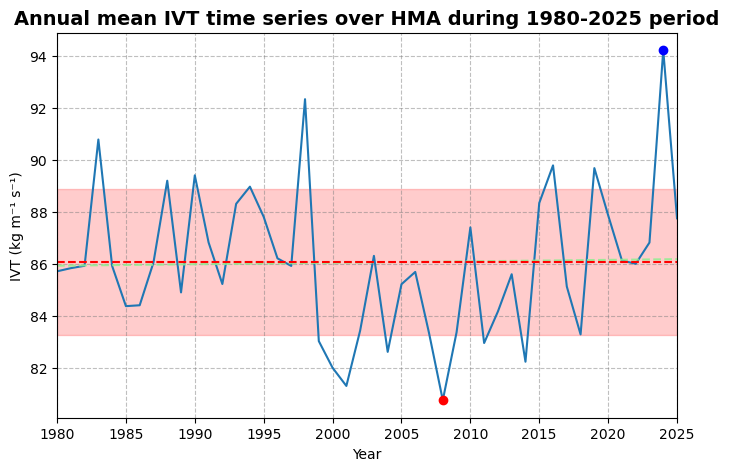

In [6]:
print(f'Trend : {slope:.2f} kg m⁻¹ s⁻¹ / year (p-value = {p_value:.3f})\n'
    f'Mean = {np.mean(ivt_mean.values):.2f} kg m⁻¹ s⁻¹\n'
    f'Std = {np.std(ivt_mean.values):.2f} kg m⁻¹ s⁻¹\n'
    f'Min = {np.min(ivt_mean.values):.2f} kg m⁻¹ s⁻¹\n'
    f'Max = {np.max(ivt_mean.values):.2f} kg m⁻¹ s⁻¹\n')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(ivt_mean['year'].values, ivt_mean.values)

ax.plot(ivt_mean['year'].values, trend, linestyle='--', color='lightgreen', alpha=0.85)
ax.axhline(np.mean(ivt_mean.values), linestyle='--', color='Red')
ax.fill_between(ivt_mean['year'].values,
                np.mean(ivt_mean.values) - np.std(ivt_mean.values),np.mean(ivt_mean.values) + np.std(ivt_mean.values),
                color='red',alpha=0.2)

# Min et Max
year_min = ivt_mean['year'].values[np.argmin(ivt_mean.values)]
year_max = ivt_mean['year'].values[np.argmax(ivt_mean.values)]
val_min=ivt_mean.values[np.argmin(ivt_mean.values)]
val_max=ivt_mean.values[np.argmax(ivt_mean.values)]

ax.scatter(year_min, val_min, zorder=5, color='Red')  
ax.scatter(year_max, val_max, zorder=5, color='Blue')

ax.set_xlim(iyear, fyear)

ax.set_xlabel('Year')
ax.set_ylabel('IVT (kg m⁻¹ s⁻¹)')

ax.set_title(f'Annual mean IVT time series over {dom} during {iyear}-{fyear} period', fontsize=14, weight='bold')
ax.grid(linestyle='--', color='gray', alpha=0.5)

plt.show()

# IVT season time series

In [8]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
mean_dict = {}
trend_dict = {}

#Rename time dimension for 'clim' function
#ivt = ivt.rename({'valid_time': 'time'})

#Climatology for each season
for season in seasons:
    ivt_season,_ = seasonal_selection(ivt['ivt'], season, start_year, end_year)
    ivt_mean=ivt_season.mean(dim=['latitude','longitude'])
    trend = stats.linregress(ivt_mean['time'].values, ivt_mean.values)
    
    mean_dict[season]=ivt_mean
    trend_dict[season]=trend

(D- 1980  JF- 1981  to D- 2025 JF- 2026


---- DJFM ----

Trend : -0.10 kg m⁻¹ s⁻¹ / year (p-value = 0.051)	Mean = 57.88 kg m⁻¹ s⁻¹	Std = 4.42 kg m⁻¹ s⁻¹	Min = 49.01 kg m⁻¹ s⁻¹	Max = 69.51 kg m⁻¹ s⁻¹

---- AM ----

Trend : -0.03 kg m⁻¹ s⁻¹ / year (p-value = 0.661)	Mean = 91.33 kg m⁻¹ s⁻¹	Std = 5.69 kg m⁻¹ s⁻¹	Min = 81.99 kg m⁻¹ s⁻¹	Max = 107.85 kg m⁻¹ s⁻¹

---- JJAS ----

Trend : 0.07 kg m⁻¹ s⁻¹ / year (p-value = 0.143)	Mean = 123.51 kg m⁻¹ s⁻¹	Std = 4.35 kg m⁻¹ s⁻¹	Min = 116.84 kg m⁻¹ s⁻¹	Max = 135.26 kg m⁻¹ s⁻¹

---- ON ----

Trend : 0.07 kg m⁻¹ s⁻¹ / year (p-value = 0.061)	Mean = 61.68 kg m⁻¹ s⁻¹	Std = 3.33 kg m⁻¹ s⁻¹	Min = 53.69 kg m⁻¹ s⁻¹	Max = 68.82 kg m⁻¹ s⁻¹



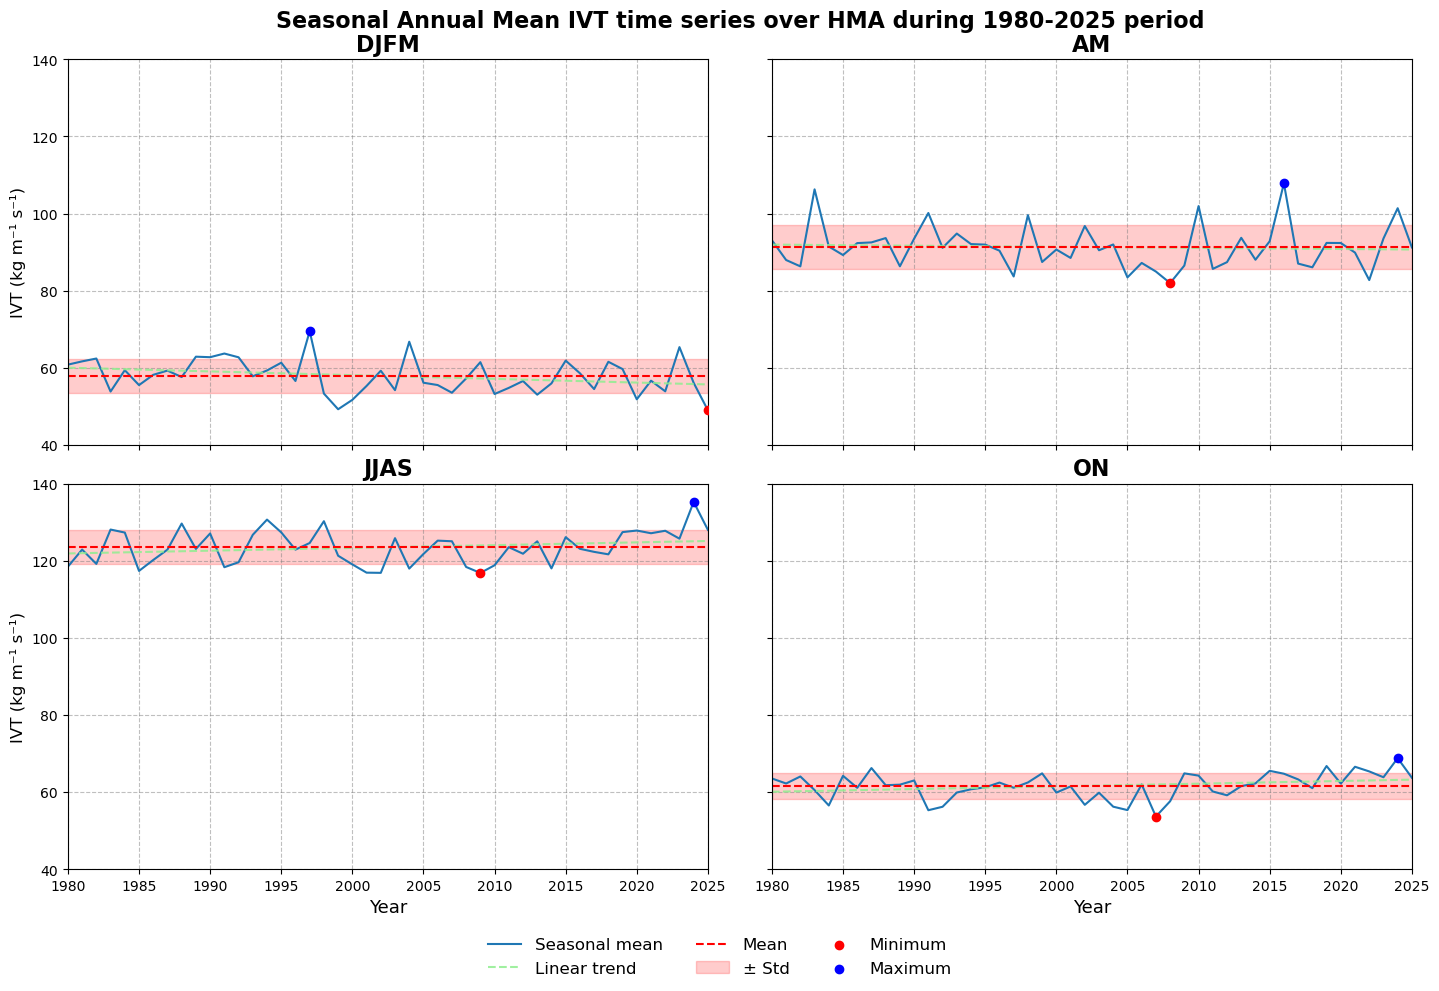

In [13]:
for season in seasons:
    print(f"---- {season} ----\n")
    
    print(f'Trend : {trend_dict[season][0]:.2f} kg m⁻¹ s⁻¹ / year (p-value = {trend_dict[season][3]:.3f})\t'
    f'Mean = {np.mean(mean_dict[season].values):.2f} kg m⁻¹ s⁻¹\t'
    f'Std = {np.std(mean_dict[season].values):.2f} kg m⁻¹ s⁻¹\t'
    f'Min = {np.min(mean_dict[season].values):.2f} kg m⁻¹ s⁻¹\t'
    f'Max = {np.max(mean_dict[season].values):.2f} kg m⁻¹ s⁻¹\n')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]

    trend = trend_dict[season][1]+trend_dict[season][0]*mean_dict[season]['time'].values
    
    ax.plot(mean_dict[season]['time'].values, mean_dict[season].values,label='Seasonal mean' if i == 0 else None)
    
    ax.plot(mean_dict[season]['time'].values, trend, linestyle='--', color='lightgreen', alpha=0.85,label='Linear trend' if i == 0 else None)
    ax.axhline(np.mean(mean_dict[season].values), linestyle='--', color='Red', label='Mean' if i == 0 else None)
    ax.fill_between(mean_dict[season]['time'].values,
                    np.mean(mean_dict[season].values) - np.std(mean_dict[season].values),
                    np.mean(mean_dict[season].values) + np.std(mean_dict[season].values),
                    color='red',alpha=0.2, label='± Std')
    
    # Min et Max
    year_min = mean_dict[season]['time'].values[np.argmin(mean_dict[season].values)]
    year_max = mean_dict[season]['time'].values[np.argmax(mean_dict[season].values)]
    val_min=mean_dict[season].values[np.argmin(mean_dict[season].values)]
    val_max=mean_dict[season].values[np.argmax(mean_dict[season].values)]
    
    ax.scatter(year_min, val_min, zorder=5, color='Red', label='Minimum' if i == 0 else None)
    ax.scatter(year_max, val_max, zorder=5, color='Blue', label='Maximum' if i == 0 else None)

    if i in [0, 2]:  # colonne gauche
        ax.set_ylabel('IVT (kg m⁻¹ s⁻¹)', fontsize=12)
        ax.tick_params(labelleft=True)
    else:
        ax.tick_params(labelleft=False)  # pas de labels pour colonne droite

    if i in [2, 3]:  # ligne du bas
        ax.set_xlabel('Year', fontsize=13)
        ax.tick_params(labelbottom=True)
    else:
        ax.tick_params(labelbottom=False)  # pas de labels pour ligne du haut
    
    ax.set_title(season, fontsize=16, weight="bold")
    
    ax.set_xlim(iyear, fyear)
    ax.set_ylim(40,140)
    ax.grid(linestyle='--', color='gray', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,loc='lower center',ncol=3,fontsize=12,frameon=False)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0.1)
fig.suptitle(f'Seasonal Annual Mean IVT time series over {dom} during {iyear}-{fyear} period', fontsize=16, weight='bold')

plt.show()